# 02 - Tree-Based Causal Methods

Uplift Random Forest (causalml), Causal Forest / GRF (econml.grf), and a single Honest Causal Tree. Unlike meta-learners, these methods target treatment-effect heterogeneity directly in the tree split criterion. Because ground-truth $\tau$ is unobserved, causal forests cannot be tuned by ordinary CV MSE; notebook 05 uses DR-loss as the model-selection surrogate.

## Setup

Same fixed-seed, stratified split as notebook 01. Trees do not need scaling - we feed raw features.

In [1]:
ARTIFACT_NAME = '02_tree_methods'
import time, warnings, pickle, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from criteo_data import fetch_criteo
from sklift.metrics import uplift_auc_score, qini_auc_score, uplift_at_k

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

SEED = 42
np.random.seed(SEED)
SAMPLE_SIZE = 500_000

print('Loading Criteo...')
ds = fetch_criteo(target_col='conversion')
X_full, y_full, treat_full = ds.data, ds.target, ds.treatment
if SAMPLE_SIZE and SAMPLE_SIZE < len(X_full):
    idx = np.random.choice(len(X_full), SAMPLE_SIZE, replace=False)
    X_full = X_full.iloc[idx].reset_index(drop=True)
    y_full = y_full.iloc[idx].reset_index(drop=True)
    treat_full = treat_full.iloc[idx].reset_index(drop=True)

strat = treat_full.values * 2 + y_full.values
X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
    X_full.values, y_full.values, treat_full.values,
    test_size=0.2, random_state=SEED, stratify=strat,
)
print(f'Train: {len(X_train):,}  Test: {len(X_test):,}')

results = {}
qini_curves = {}

def evaluate(name, scores, elapsed):
    s = np.asarray(scores).flatten()
    row = {
        'AUUC':       round(uplift_auc_score(y_test, s, t_test), 6),
        'Qini':       round(qini_auc_score(y_test, s, t_test),   6),
        'Uplift@10%': round(uplift_at_k(y_test, s, t_test, strategy='by_group', k=0.1), 4),
        'Uplift@20%': round(uplift_at_k(y_test, s, t_test, strategy='by_group', k=0.2), 4),
        'Time(s)':    round(elapsed, 1),
    }
    results[name] = row
    qini_curves[name] = s
    print(f'[{name:<28}]  Qini={row["Qini"]:.6f}  @10%={row["Uplift@10%"]:.4f}  @20%={row["Uplift@20%"]:.4f}  time={row["Time(s)"]}s')
    return row


Loading Criteo...


Train: 400,000  Test: 100,000


## 1. Uplift Random Forest (causalml)

Rzepakowski & Jaroszewicz (2010): split to maximize a divergence (KL here) between the treated- and control-arm outcome distributions in the child nodes - a direct CATE estimator with no nuisance models. Not honest and no built-in inference: splits and leaf estimates use the same data, so in-sample estimates are biased. With rare positives (~0.3% CR) small leaves give noisy per-arm rates; we use `min_samples_leaf` of 200. API note: `UpliftRandomForestClassifier` lives in `causalml.inference.tree`, takes treatment as string labels, and requires a `control_name` string.

In [2]:
# Uplift Random Forest lives in causalml (not scikit-uplift). It requires a
# string `control_name` and returns a 2D (n_samples, n_treatments) array.
from causalml.inference.tree import UpliftRandomForestClassifier

t0 = time.time()
urf = UpliftRandomForestClassifier(
    control_name='0',
    n_estimators=100, max_depth=8, min_samples_leaf=200,
    evaluationFunction='KL', random_state=SEED, n_jobs=-1,
)
urf.fit(X=X_train, treatment=t_train.astype(str), y=y_train)
scores = np.asarray(urf.predict(X_test))
# causalml returns (n_samples, n_treatments); single treatment here -> column 0
if scores.ndim == 2:
    scores = scores[:, 0]
evaluate('UpliftRF (KL)', scores, time.time() - t0)

Failed to import duecredit due to No module named 'duecredit'


[UpliftRF (KL)               ]  Qini=0.117374  @10%=0.0100  @20%=0.0043  time=83.0s


{'AUUC': 0.003954,
 'Qini': 0.117374,
 'Uplift@10%': 0.01,
 'Uplift@20%': 0.0043,
 'Time(s)': 83.0}

## 2. Causal Forest (GRF)

Generalized Random Forest (Athey, Tibshirani & Wager 2019): trees act as an adaptive kernel and a Robinson-style orthogonal moment is solved locally - DML at the leaf level. Trees are honest (split selection and leaf estimation use disjoint subsamples), which is what makes the pointwise variance estimates valid; econml computes them with a bootstrap-of-little-bags scheme (the `subforest_size` groups). Criteo is friendly territory for the asymptotics: low dimension, perfect overlap, large n.

In [3]:
from econml.grf import CausalForest

t0 = time.time()
cf = CausalForest(
    n_estimators=200, min_samples_leaf=200, max_depth=None,
    honest=True, inference=True, random_state=SEED, n_jobs=-1,
)
cf.fit(X_train, t_train, y_train)
tau_cf = cf.predict(X_test).flatten()
evaluate('CausalForest (GRF)', tau_cf, time.time() - t0)

[CausalForest (GRF)          ]  Qini=0.185171  @10%=0.0127  @20%=0.0067  time=22.8s


{'AUUC': 0.006235,
 'Qini': 0.185171,
 'Uplift@10%': 0.0127,
 'Uplift@20%': 0.0067,
 'Time(s)': 22.8}

### Confidence intervals and persuadable segments

With honesty and `inference=True`, `cf.predict(..., interval=True, alpha=...)` returns pointwise $(1-\alpha)$ CIs; we use $\alpha=0.10$ (90%). These are pointwise, not simultaneous: across ~100K test points about 10% of CIs falsely exclude zero by chance, so population-level claims need a multiple-testing correction. Segmentation follows [METRICS.md §3.1](METRICS.md): persuadables ($\hat\tau > 0$ and lower CI bound $> 0$), sleeping dogs ($\hat\tau < 0$ and upper CI bound $< 0$), uncertain otherwise. Segment sizes are sensitive to `min_samples_leaf` and `n_estimators`.

Persuadables : 10.4190%
Sleeping dogs: 0.0060%
Uncertain    : 89.5750%


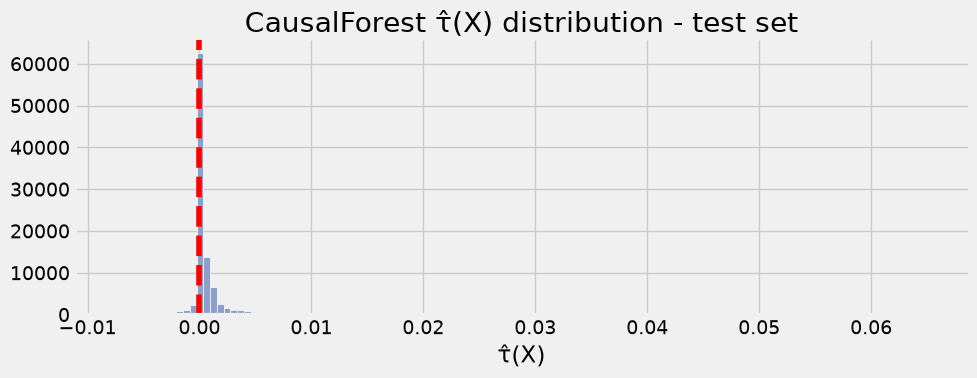

In [4]:
tau, lb, ub = cf.predict(X_test, interval=True, alpha=0.10)
tau = tau.flatten(); lb = lb.flatten(); ub = ub.flatten()

persuadable = (tau > 0) & (lb > 0)
sleeping    = (tau < 0) & (ub < 0)
uncertain   = ~(persuadable | sleeping)

print(f'Persuadables : {persuadable.mean():.4%}')
print(f'Sleeping dogs: {sleeping.mean():.4%}')
print(f'Uncertain    : {uncertain.mean():.4%}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(tau, bins=120, color='#8da0cb', edgecolor='white')
ax.axvline(0, color='red', linestyle='--')
ax.set_title('CausalForest τ̂(X) distribution - test set')
ax.set_xlabel('τ̂(X)')
plt.tight_layout(); plt.savefig('cf_tau_distribution.png', dpi=140); plt.show()

## 3. Honest Causal Tree

A single honest tree (Athey & Imbens, PNAS 2016), implemented as `CausalForest` with `n_estimators=1` and `max_depth=5` for readability. No averaging means very high variance, so expect a weak Qini; it is here for interpretation (top splits, natural segments), not prediction.

In [5]:
t0 = time.time()
hct = CausalForest(
    n_estimators=1, min_samples_leaf=2000, max_depth=5,
    honest=True, inference=False, random_state=SEED, n_jobs=-1,
)
hct.fit(X_train, t_train, y_train)
tau_hct = hct.predict(X_test).flatten()
evaluate('HonestCausalTree (depth=5)', tau_hct, time.time() - t0)

[HonestCausalTree (depth=5)  ]  Qini=0.198077  @10%=0.0108  @20%=0.0062  time=0.3s


{'AUUC': 0.006691,
 'Qini': 0.198077,
 'Uplift@10%': 0.0108,
 'Uplift@20%': 0.0062,
 'Time(s)': 0.3}

## Results

The leaderboard sorted by Qini. With only ~300 conversions in the hold-out, Qini is noisy: notebook 06's bootstrap puts the per-model standard error at roughly 0.03-0.07 on sklift's normalized scale, so most of these differences are within noise. Read the bootstrap tiers in notebook 06, not this raw ordering.

In [6]:
df = pd.DataFrame(results).T.astype(float).sort_values('Qini', ascending=False)
print('\n=== Leaderboard ===')
print(df.to_string(float_format=lambda x: f'{x:.6f}' if abs(x) < 10 else f'{x:.1f}'))
df.style.background_gradient(subset=['AUUC','Qini','Uplift@10%','Uplift@20%'], cmap='Greens') \
        .background_gradient(subset=['Time(s)'], cmap='Reds_r') \
        .format({'AUUC':'{:.6f}','Qini':'{:.6f}','Uplift@10%':'{:.4f}','Uplift@20%':'{:.4f}','Time(s)':'{:.1f}'})



=== Leaderboard ===
                               AUUC     Qini  Uplift@10%  Uplift@20%  Time(s)
HonestCausalTree (depth=5) 0.006691 0.198077    0.010800    0.006200 0.300000
CausalForest (GRF)         0.006235 0.185171    0.012700    0.006700     22.8
UpliftRF (KL)              0.003954 0.117374    0.010000    0.004300     83.0


,AUUC,Qini,Uplift@10%,Uplift@20%,Time(s)
HonestCausalTree (depth=5),0.006691,0.198077,0.0108,0.0062,0.3
CausalForest (GRF),0.006235,0.185171,0.0127,0.0067,22.8
UpliftRF (KL),0.003954,0.117374,0.0100,0.0043,83.0


### Qini curves

All three models on one plot.

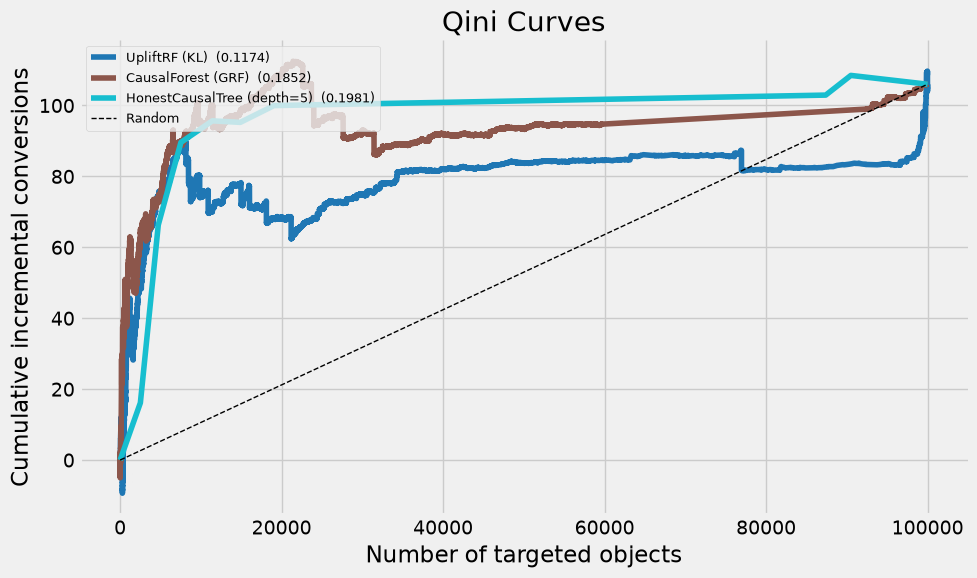

In [7]:
# We draw the Qini curves by hand with sklift.metrics.qini_curve. Calling
# plot_qini_curve several times on one axis crashes on matplotlib >= 3.7.
from sklift.metrics import qini_curve
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(qini_curves)))
end = None
for (name, s), c in zip(qini_curves.items(), colors):
    x, y = qini_curve(y_test, np.asarray(s).flatten(), t_test)
    ax.plot(x, y, label=f'{name}  ({results[name]["Qini"]:.4f})', color=c)
    end = (x[-1], y[-1])
if end is not None:
    ax.plot([0, end[0]], [0, end[1]], 'k--', lw=1, label='Random')
ax.set_xlabel('Number of targeted objects')
ax.set_ylabel('Cumulative incremental conversions')
ax.set_title('Qini Curves')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.savefig(f'{ARTIFACT_NAME}_qini.png', dpi=140, bbox_inches='tight'); plt.show()

In [8]:
# Persist results for the final benchmark notebook
os.makedirs('artifacts', exist_ok=True)
with open(f'artifacts/{ARTIFACT_NAME}.pkl', 'wb') as f:
    pickle.dump({'results': results, 'qini_curves': qini_curves,
                 'y_test': y_test, 't_test': t_test}, f)
print(f"Saved artifacts/{ARTIFACT_NAME}.pkl")


Saved artifacts/02_tree_methods.pkl


Next: [03_dml.ipynb](03_dml.ipynb).